<a href="https://colab.research.google.com/github/medpadalc/Semantic-Segmentation-for-Natural-Terrains/blob/main/Model_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Setup

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

from google.colab import drive
drive.mount('/content/drive')

root_dir = '/content/drive/MyDrive/Medhya Padmanabhuni - Winter I 2025/project'

Mounted at /content/drive


In [ ]:
!unzip "{root_dir}/RUGD_annotations.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/RUGD_annotations/trail/trail_00141.png  
  inflating: /content/RUGD_annotations/trail/trail_03026.png  
  inflating: /content/RUGD_annotations/trail/trail_00646.png  
  inflating: /content/RUGD_annotations/trail/trail_00181.png  
  inflating: /content/RUGD_annotations/trail/trail_02106.png  
  inflating: /content/RUGD_annotations/trail/trail_00021.png  
  inflating: /content/RUGD_annotations/trail/trail_02126.png  
  inflating: /content/RUGD_annotations/trail/trail_02281.png  
  inflating: /content/RUGD_annotations/trail/trail_03306.png  
  inflating: /content/RUGD_annotations/trail/trail_00551.png  
  inflating: /content/RUGD_annotations/trail/trail_02881.png  
  inflating: /content/RUGD_annotations/trail/trail_01911.png  
  inflating: /content/RUGD_annotations/trail/trail_00611.png  
  inflating: /content/RUGD_annotations/trail/trail_02791.png  
  inflating: /content/RUGD_annotations/trail/trail_01281.png  
  in

In [ ]:
!unzip "{root_dir}/RUGD_frames-with-annotations.zip" -d "/content/"
# NOTE: if you run out of memory, use the "...mini.zip" file instead

Streaming output truncated to the last 5000 lines.
  inflating: /content/RUGD_frames-with-annotations/park-1/park-1_00106.png  
  inflating: /content/__MACOSX/RUGD_frames-with-annotations/park-1/._park-1_00106.png  
  inflating: /content/RUGD_frames-with-annotations/park-1/park-1_02711.png  
  inflating: /content/__MACOSX/RUGD_frames-with-annotations/park-1/._park-1_02711.png  
  inflating: /content/RUGD_frames-with-annotations/park-1/park-1_01581.png  
  inflating: /content/__MACOSX/RUGD_frames-with-annotations/park-1/._park-1_01581.png  
  inflating: /content/RUGD_frames-with-annotations/park-1/park-1_02936.png  
  inflating: /content/__MACOSX/RUGD_frames-with-annotations/park-1/._park-1_02936.png  
  inflating: /content/RUGD_frames-with-annotations/park-1/park-1_00846.png  
  inflating: /content/__MACOSX/RUGD_frames-with-annotations/park-1/._park-1_00846.png  
  inflating: /content/RUGD_frames-with-annotations/park-1/park-1_00661.png  
  inflating: /content/__MACOSX/RUGD_frames-with

# 2. Imports and function defs

In [ ]:
import os
import random
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.io.image import decode_image
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.transforms.functional import to_pil_image
from tqdm.auto import tqdm

# Determine if this Colab instand has access to a GPU (CUDA), which makes ML code faster
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Configure the random seed to make results more reproducible
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

In [ ]:
class RUGDDataset(Dataset):

    # SUBDIR_SPLIT = {
    #     'train': ['park-1', 'trail-15', 'trail-3', 'trail-4', 'trail-5', 'trail-6', 'trail-7', 'trail-9'],
    #     'validation': ['village', 'park-2', 'trail-14'],
    #     # 'test': ['creek', 'park-8', 'trail'],
    #     # 'test': ['creek'],
    #     # 'test': ['trail'],
    #     'test': ['park-8'],
    # }
# switched around the files
    SUBDIR_SPLIT = {
        'train': ['park-1', 'trail-15', 'trail-3', 'trail-4', 'trail-5', 'trail-6', 'trail-7', 'trail-10'],
        'validation': ['village', 'park-2', 'trail-14'],
        'test': ['creek', 'park-8', 'trail-9'],
        # 'test': ['creek'],
        # 'test': ['trail-9'],
        # 'test': ['park-8'],
    }


    def __init__(self, split, root_dir='/content/', tform=None):
        self.im_dir = os.path.join(root_dir, 'RUGD_frames-with-annotations')
        self.label_dir = os.path.join(root_dir, 'RUGD_annotations')
        self.split = split
        self.tform = tform

        self.paths = self.create_path_list()  # paired filenames for RGB and label images
        self.int_to_class_map = self.load_color_class_map()  # (R, G, B) -> class index

    def load_color_class_map(self):
        int_to_class_map = {}
        classes = []
        with open(os.path.join(self.label_dir, 'RUGD_annotation-colormap.txt'), 'r') as file:
            for line in file:
                i, title, r, g, b = line.rstrip().split(' ')
                i, r, g, b = int(i), int(r), int(g), int(b)
                classes.append(title)
                int_to_class_map[self.color_to_int((r, g, b))] = i
        return int_to_class_map

    def color_to_int(self, color):
        r, g, b = color[0], color[1], color[2]
        return r + g * 256 + b * 256**2

    def color_to_class(self, color):
        color_int = self.color_to_int(color)
        is_ndim = type(color_int) in [torch.Tensor, np.ndarray]

        if is_ndim:
            class_label = np.copy(color_int)
            for k, v in self.int_to_class_map.items():
                class_label[color_int == k] = v
            return class_label
        else:
            return self.int_to_class_map[color_int]

    def create_path_list(self):
        # todo: make sure file exists in both directories?
        # subdirs = [f.path for f in os.scandir(self.im_dir) if f.is_dir()]
        subdirs = [
            os.path.join(self.im_dir, subdir)
            for subdir in RUGDDataset.SUBDIR_SPLIT[self.split]
        ]
        paths = []
        for dir in subdirs:
            paths_ = glob(os.path.join(self.im_dir, dir, '*.png'))
            for path in paths_:
                fname = os.path.basename(path)

                if path.endswith('trail/trail_02551.png'):
                    # Hardcoded fix for corrupted file
                    continue

                path1 = os.path.join(self.label_dir, os.path.basename(dir), fname)
                path2 = path
                paths.append([path1, path2])
        return pd.DataFrame(paths, columns=['label_path', 'im_path'])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        row = self.paths.iloc[i]
        im = decode_image(row['im_path'])
        color_label = decode_image(row['label_path'])
        class_label = torch.from_numpy(self.color_to_class(color_label))
        if self.tform:
            im = self.tform(im)
        return im, class_label


In [ ]:
!pip install -U segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.5 MB/s eta 0:00:00


# 3. Benchmarking the "basic" PASCAL-pretrained model on RUGD data

In [ ]:
PASCAL_TO_RUGD = {
    0: 17,   # person → person
    1: 16,   # bicycle → bicycle
    2: 8,    # car → vehicle
    3: 8,    # motorbike → vehicle
    4: 0,    # aeroplane → void
    5: 8,    # bus → vehicle
    6: 8,    # train → vehicle
    7: 8,    # boat → vehicle
    8: 0,    # bird → void
    9: 0,    # cat → void
    10: 0,   # dog → void
    11: 0,   # horse → void
    12: 0,   # sheep → void
    13: 0,   # cow → void
    14: 0,   # elephant → void
    15: 0,   # bear → void
    16: 0,   # zebra → void
    17: 0,   # giraffe → void
    18: 0,   # potted plant → void
    19: 0,   # void → void
    20: 0,
}

def convert_to_rugd_labels(pascal_labels):
    # converts PASCAL labels to RUGD labels
    # input: pascal_labels torch.tensor of size (h, w), 21(or 20?) classes
    # output: rugd labels, 25 classes

    # ex. if PASCAL class bike = 2 and RUGD class bike = 4, convert all 2s to 4s
    # if PASCAL class isn't present, then convert it to the RUGD void class

    ######### TODO: Q1 in the Week 5 Assignment ##########
    ######################################################
    rugd_labels = torch.zeros_like(pascal_labels)

    for pascal_id, rugd_id in PASCAL_TO_RUGD.items():
        rugd_labels[pascal_labels == pascal_id] = rugd_id

    return rugd_labels


In [ ]:
def accuracy_fn(pred, target):
    num_correct = ((pred == target) & (pred == 0)).sum()
    if (pred == 0).sum() == 0:
        return 1
    return num_correct / (pred == 0).sum()

def classwise_acc_fn(pred, target, num_classes=25):
    correct = pred == target
    class_accs = []
    for i in range(num_classes):
        target_i = target == i
        num_correct = (correct * target_i).sum()
        acc = num_correct / target_i.sum()
        if torch.isnan(acc):
            acc = 0
        class_accs.append(acc)
    return torch.tensor(class_accs)

In [ ]:
weights = DeepLabV3_ResNet50_Weights.DEFAULT
preprocess = weights.transforms()
model = deeplabv3_resnet50(weights=weights).to(device).eval()
resize_fn = torchvision.transforms.Resize((550, 688))

criteria = [
    # classwise_acc_fn,
    accuracy_fn,
    # torch.nn.CrossEntropyLoss(),
    ######## TODO: Q2 in the Week 5 Assignment ###########
    # add more losses/metrics here!
    ######################################################
]
running_criteria = [0 for _ in criteria]

ds = RUGDDataset('train')
train_loader = DataLoader(
    ds, batch_size=16, shuffle=True,
)
ds = RUGDDataset('test')
test_loader = DataLoader(
    ds, batch_size=16, shuffle=True,
)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 243MB/s]


In [ ]:
# Evaluation loop


# all_pred_labels = []
# all_target_labels = []

for i, batch in enumerate(tqdm(test_loader)):
    im, label = batch
    im = im.to(device)
    im = preprocess(im)
    label = label.to(device)

    with torch.no_grad():
        pred = model(im)['out']

    pred = resize_fn(pred)
    pred_label = torch.argmax(pred, axis=1)

    ######### TODO: Q1 in the Week 5 Assignment ##########
    pred_label = convert_to_rugd_labels(pred_label)
    ######################################################

    running_criteria = [
        c_val + criterion(pred_label, label.long())
        for (c_val, criterion) in zip(running_criteria, criteria)
    ]
running_criteria = [c_val / len(train_loader) for c_val in running_criteria]

#     all_pred_labels.append(pred_label)
#     all_target_labels.append(label)

# all_pred_labels = torch.cat(all_pred_labels)#.view(-1)
# all_target_labels = torch.cat(all_target_labels)#.view(-1)


  0%|          | 0/75 [00:00<?, ?it/s]

In [ ]:
running_criteria

[tensor(0.0286, device='cuda:0')]

In [ ]:
# skip
# from sklearn.metrics import confusion_matrix

# pred = all_pred_labels[:100].cpu().numpy().ravel()
# target = all_target_labels[:100].cpu().numpy().ravel()

# mtx = confusion_matrix(target, pred, normalize='true')

NameError: name 'all_pred_labels' is not defined

In [ ]:
# skip
# from sklearn.metrics import ConfusionMatrixDisplay

# disp = ConfusionMatrixDisplay(mtx)
# disp.plot()

NameError: name 'mtx' is not defined

In [ ]:
# skip
# Use the following code for plotting/debugging

# plt.subplot(131)
# plt.imshow(pred[0].softmax(axis=0).argmax(dim=0))
# plt.subplot(132)
# plt.imshow(label[0])
# plt.subplot(133)
# plt.imshow(im[0].permute(1, 2, 0))

# 4. Model fine-tuning

This might be helpful: https://madebyollin.github.io/convnet-calculator/

In [ ]:
from segmentation_models_pytorch.losses import DiceLoss
from segmentation_models_pytorch.losses import FocalLoss

In [ ]:
weights = DeepLabV3_ResNet50_Weights.DEFAULT
PREPROCESS_FN = weights.transforms()
RESIZE_FN = torchvision.transforms.Resize((550, 688))

In [ ]:
def validation_acc(val_loader, model):
    running_acc = 0
    model.eval()
    for batch in val_loader:
        im, label = batch
        im = im.to(device)
        im = PREPROCESS_FN(im)
        label = label.to(device)

        with torch.no_grad():
            pred = model(im)
        pred = RESIZE_FN(pred)
        pred_label = pred.argmax(axis=1)
        acc = (pred_label == label).sum() / label.numel()
        running_acc += acc
    model.train()
    return running_acc / len(val_loader)

In [ ]:
# https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.segmentation.deeplabv3_resnet50.html#torchvision.models.segmentation.deeplabv3_resnet50

# Our model from Week 4

class TerrainModel(nn.Module):

    def __init__(self, kernel_size=1):
        super().__init__()
        # wraps the pretrained model and adds a new layer with the correct number of output classes
        weights = DeepLabV3_ResNet50_Weights.DEFAULT
        self.pretrained_model = deeplabv3_resnet50(weights=weights)
        self.final_layer = nn.Conv2d(21, 25, kernel_size)

    def forward(self, x):
        y = self.pretrained_model(x)['out']
        return self.final_layer(y)


In [ ]:
class CustomModel_1(nn.Module):
    def __init__(self, kernel_size=1):
        super().__init__()
        weights = DeepLabV3_ResNet50_Weights.DEFAULT
        self.pretrained_model = deeplabv3_resnet50(weights=weights)
        self.final_layer = nn.Conv2d(21, 25, kernel_size, padding=5, stride=1)
        # nn.Conv2d(21, 25, kernel_size, padding=9)

    def forward(self, x):
        y = self.pretrained_model(x)['out']
        return self.final_layer(y)

In [ ]:
class OnlyModel(nn.Module):
    def __init__(self, kernel_size=1):
        super().__init__()
        weights = DeepLabV3_ResNet50_Weights.DEFAULT
        self.pretrained_model = deeplabv3_resnet50(weights=weights)
        # self.final_layer = nn.Conv2d(21, 25, kernel_size, padding=5, stride=1)
        # nn.Conv2d(21, 25, kernel_size, padding=9)

    def forward(self, x):
        y = self.pretrained_model(x)['out']
        return y

In [ ]:
class CustomModel_3(nn.Module):
    def __init__(self, kernel_size=1):
        super().__init__()
        weights = DeepLabV3_ResNet50_Weights.DEFAULT
        self.pretrained_model = deeplabv3_resnet50(weights=weights)
        self.one_layer = nn.Conv2d(21, 32, kernel_size, padding=2)
        self.two_layer = nn.Conv2d(32, 32, kernel_size, padding=2)
        self.final_layer = nn.Conv2d(32, 25, kernel_size, padding=2)

        self.one_batchnorm = nn.BatchNorm2d(32)
        self.two_batchnorm = nn.BatchNorm2d(32)

        self.relu = nn.ReLU()


    def forward(self, x):
        y = self.pretrained_model(x)['out']

        y = self.one_layer(y)
        y = self.one_batchnorm(y)
        y = self.relu(y)

        y = self.two_layer(y)
        y = self.two_batchnorm(y)
        y = self.relu(y)

        return self.final_layer(y)

In [ ]:
class CustomModel_5(nn.Module):
    def __init__(self, kernel_size=1):
        super().__init__()
        weights = DeepLabV3_ResNet50_Weights.DEFAULT
        self.pretrained_model = deeplabv3_resnet50(weights=weights)
        self.one_layer = nn.Conv2d(21, 32, kernel_size)
        self.two_layer = nn.Conv2d(32, 32, kernel_size)
        self.three_layer = nn.Conv2d(32, 32, kernel_size)
        self.four_layer = nn.Conv2d(32, 32, kernel_size)
        self.final_layer = nn.Conv2d(32, 25, kernel_size)

        self.one_batchnorm = nn.BatchNorm2d(32)
        self.two_batchnorm = nn.BatchNorm2d(32)
        self.three_batchnorm = nn.BatchNorm2d(32)
        self.four_batchnorm = nn.BatchNorm2d(32)

        self.relu = nn.ReLU()


    def forward(self, x):
        y = self.pretrained_model(x)['out']

        y = self.one_layer(y)
        y = self.one_batchnorm(y)
        y = self.relu(y)

        y = self.two_layer(y)
        y = self.two_batchnorm(y)
        y = self.relu(y)

        y = self.three_layer(y)
        y = self.three_batchnorm(y)
        y = self.relu(y)

        y = self.four_layer(y)
        y = self.four_batchnorm(y)
        y = self.relu(y)

        return self.final_layer(y)

In [ ]:
# Hyperparameters ################
# LR = 0.0008
BATCH_SIZE = 30
NUM_EPOCHS = 40
KERNEL_SIZE1 = 11

# LR = 0.0006
LR = 0.0001 # for different kernel size!
# BATCH_SIZE = 35
# NUM_EPOCHS = 10
KERNEL_SIZE3 = 5
##################################

train_loader = DataLoader(
    RUGDDataset('train'),
    batch_size=BATCH_SIZE, shuffle=True,
)
val_loader = DataLoader(
    RUGDDataset('validation'),
    batch_size=BATCH_SIZE, shuffle=False,
)

# ds = RUGDDataset('test')
# test_loader = DataLoader(
#     ds, batch_size=16, shuffle=True,
# )

# TODO: change `TerrainModel` to your custom model
model = CustomModel_1(KERNEL_SIZE1).to(device) # 1 layers
# model = CustomModel_3(KERNEL_SIZE3).to(device) # 3 layers
# model = CustomModel_5(KERNEL_SIZE3).to(device) # 5 layers
model = OnlyModel(KERNEL_SIZE1).to(device) # 0 layers

#### DO NOT change the code below ###
for param in model.pretrained_model.parameters():
    param.requires_grad = False
for param in model.pretrained_model.aux_classifier.parameters():
    param.requires_grad = True
for param in model.pretrained_model.aux_classifier[-1].parameters():
    param.requires_grad = True
#####################################

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss() #DiceLoss('multiclass') #nn.CrossEntropyLoss()
# loss_fn2 = DiceLoss('multiclass') # ADDED FOR DICE LOSS, didn't increase accuracy a lot
loss_fn2 = FocalLoss('multiclass') # ADDED FOR FOCAL LOSS

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 249MB/s]


In [ ]:
losses = []
accs = []

for epoch in range(NUM_EPOCHS):
    running_loss = 0
    pbar_prefix = f'Epoch {epoch + 1}/{NUM_EPOCHS}'
    pbar = tqdm(train_loader, desc=pbar_prefix)
    for i, batch in enumerate(pbar):
        optimizer.zero_grad()

        im, label = batch
        im = im.to(device)
        im_original_size = im.shape[-2:]
        im = PREPROCESS_FN(im)
        model_input_size = im.shape[-2:]
        label = label.to(device)

        pred = model(im)
        model_output_size = pred.shape[-2:]
        pred = RESIZE_FN(pred)
        final_output_size = pred.shape[-2:]

        assert im_original_size == final_output_size
        assert model_input_size == model_output_size

        loss1 = loss_fn(pred, label.long())
        # Uncomment the code below if you want to use multiple loss functions
        # loss2 = loss_fn2(pred, label.long())  # CHANGED A BIT
        # loss = loss1 + 0.5 * loss2 # play around with constant
        loss = loss1 # comment when using more losses
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_description(f'{pbar_prefix} loss={running_loss / (i + 1):.4f}')

        # Display the first image and its prediction for the first batch of the first epoch
        if epoch == 2:
            # Detach tensors from GPU and convert to numpy for plotting
            input_image_display = im[0].cpu().permute(1, 2, 0).numpy() # Convert C,H,W to H,W,C
            predicted_mask_display = pred.argmax(axis=1)[0].cpu().numpy()

            plt.figure(figsize=(12, 6))
            plt.subplot(1, 2, 1)
            plt.imshow(input_image_display) # Display original image
            plt.title('Input Image (First Batch, First Epoch)')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(predicted_mask_display, cmap='viridis') # Display predicted mask
            plt.title('Predicted Mask (First Batch, First Epoch)')
            plt.axis('off')
            plt.show()

    if (epoch % 2 == 0) or (epoch == NUM_EPOCHS - 1):
        acc = validation_acc(val_loader, model)

    losses.append(running_loss / len(train_loader))
    accs.append(acc.item())
    print(acc.item())


Epoch 1/40:   0%|          | 0/56 [00:00<?, ?it/s]

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# don't use until done training model

ds = RUGDDataset('test')
test_loader = DataLoader(
    ds, batch_size=16, shuffle=True,
)

acc = validation_acc(test_loader, model)
print(acc)

tensor(0.5735, device='cuda:0')


In [ ]:
def validation_acc(val_loader, model):
    running_acc = 0
    model.eval()
    for batch in val_loader:
        im, label = batch
        im = im.to(device)
        im = PREPROCESS_FN(im)
        label = label.to(device)

        with torch.no_grad():
            pred = model(im)
        pred = RESIZE_FN(pred)
        pred_label = pred.argmax(axis=1)
        acc = (pred_label == label).sum() / label.numel()
        running_acc += acc
    model.train()
    return running_acc / len(val_loader)

validation_acc(test_loader, model)

torch.Size([16, 3, 550, 688])
tensor([[[[ -3.5712,  -4.5777,  -5.4525,  ...,  -5.3326,  -4.1805,  -3.2526],
          [ -4.4655,  -5.6145,  -6.7594,  ...,  -6.7172,  -5.3509,  -4.2855],
          [ -5.6019,  -7.0763,  -8.6270,  ...,  -8.6398,  -6.9692,  -5.5972],
          ...,
          [ -4.4061,  -5.7478,  -7.0525,  ...,  -7.7381,  -6.1225,  -4.9266],
          [ -3.4635,  -4.4666,  -5.5017,  ...,  -5.9942,  -4.6784,  -3.8808],
          [ -2.8226,  -3.6990,  -4.4385,  ...,  -4.6606,  -3.6997,  -3.1015]],

         [[ -2.1265,  -2.7200,  -3.6292,  ...,  -3.2382,  -2.8560,  -2.5561],
          [ -3.0598,  -3.9647,  -5.1905,  ...,  -4.5631,  -3.9769,  -3.3127],
          [ -3.9555,  -4.9594,  -6.2558,  ...,  -5.4836,  -4.6505,  -3.8612],
          ...,
          [ -3.2136,  -4.1201,  -5.0423,  ...,  -4.9492,  -4.0515,  -3.4180],
          [ -2.8148,  -3.5527,  -4.2810,  ...,  -4.1958,  -3.4020,  -2.9017],
          [ -2.4634,  -3.0379,  -3.4584,  ...,  -3.5366,  -2.7440,  -2.2013]],



KeyboardInterrupt: 

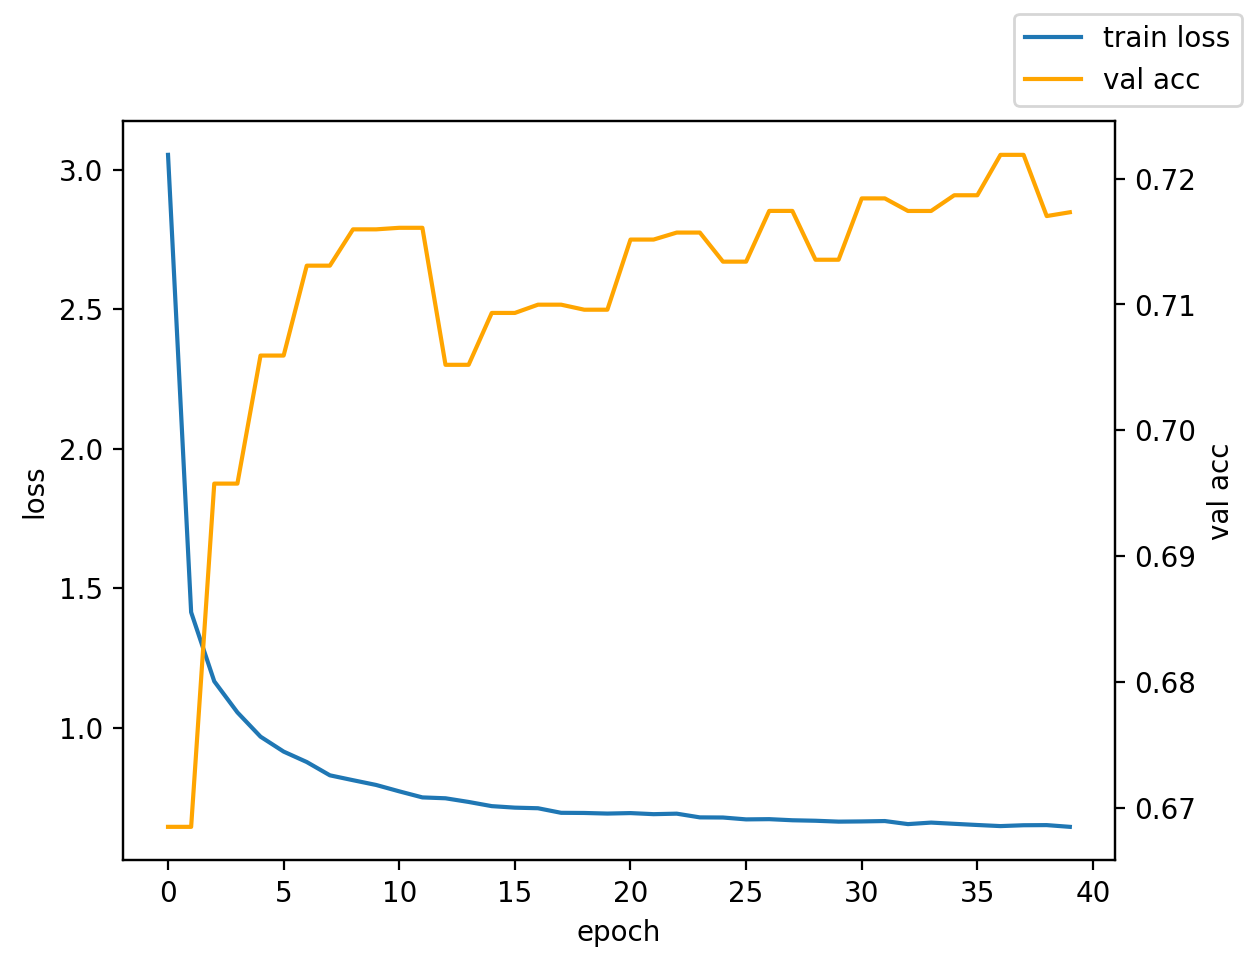

In [ ]:
fig, ax = plt.subplots()
ax.plot(losses)
ax.set_ylabel('loss')
ax2 = ax.twinx()
ax2.plot(accs, color='orange')
ax2.set_ylabel('val acc')
ax.set_xlabel('epoch')
fig.legend(['train loss', 'val acc'])

In [ ]:
accs

[0.6684693694114685,
 0.6684693694114685,
 0.6957573890686035,
 0.6957573890686035,
 0.705937385559082,
 0.705937385559082,
 0.7130849957466125,
 0.7130849957466125,
 0.7159714102745056,
 0.7159714102745056,
 0.7160948514938354,
 0.7160948514938354,
 0.705202579498291,
 0.705202579498291,
 0.7093262076377869,
 0.7093262076377869,
 0.7099830508232117,
 0.7099830508232117,
 0.7095831036567688,
 0.7095831036567688,
 0.71515953540802,
 0.71515953540802,
 0.7157157063484192,
 0.7157157063484192,
 0.7134037017822266,
 0.7134037017822266,
 0.7174376845359802,
 0.7174376845359802,
 0.713555634021759,
 0.713555634021759,
 0.7184323072433472,
 0.7184323072433472,
 0.717432975769043,
 0.717432975769043,
 0.718682050704956,
 0.718682050704956,
 0.7218949794769287,
 0.7218949794769287,
 0.7245276045799255,
 0.725944678234567]

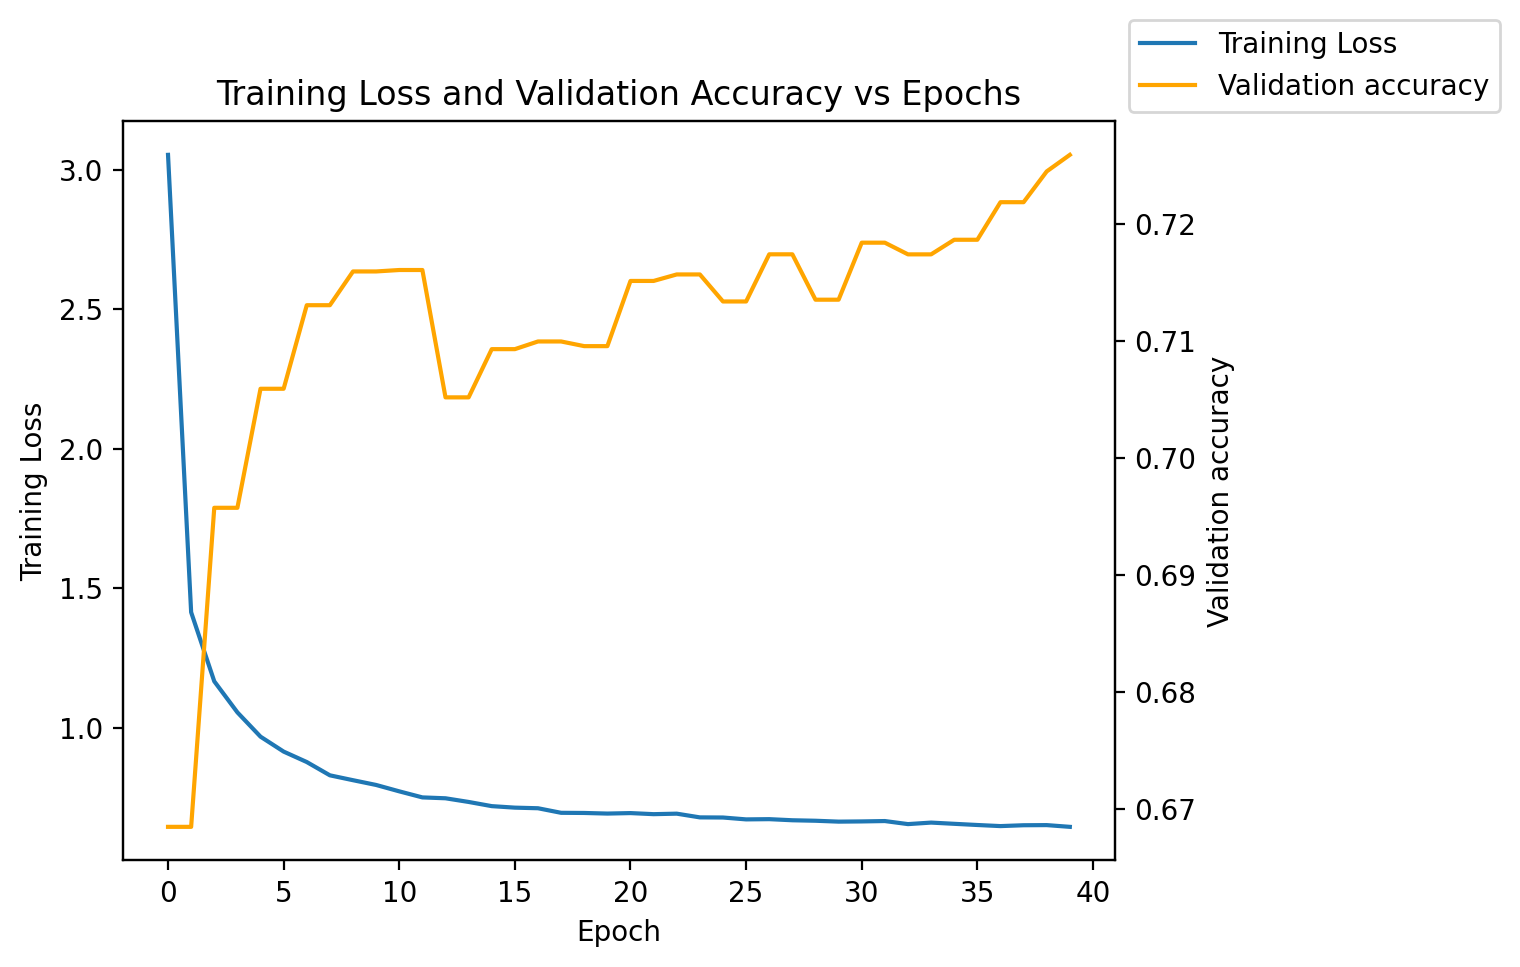

In [ ]:
fig, ax = plt.subplots()
ax.plot(losses)
ax.set_ylabel('Training Loss')
ax2 = ax.twinx()
accs[38] =   0.7245276045799255
ax2.plot(accs, color='orange')
ax2.set_ylabel('Validation accuracy')
ax.set_xlabel('Epoch')
plt.title('Training Loss and Validation Accuracy vs Epochs')
fig.legend(['Training Loss', 'Validation accuracy'], bbox_to_anchor=(0.9, 1.0), loc='upper left')